In [1]:
# ============================================================
#  IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


# **Remember: This lab has 30% of the D1 mark for the module.**

**You will be conducting an ML experiment from beginning to end for the Titanic dataset. You can download the dataset from Moodle [here](https://moodle.bcu.ac.uk/mod/folder/view.php?id=8931539&forceview=1)**

**1. You need to fill in the missing parts of the codes in the questions. You will need to write comments in the text cells.**

**2. You can get help on the code for Section 1 from [Lab 3 Exercise](https://moodle.bcu.ac.uk/mod/folder/view.php?id=8931484), Section 2 from [Lab 2 Exercise](https://moodle.bcu.ac.uk/mod/folder/view.php?id=8931483) and Section 3 from [Lab 7](https://moodle.bcu.ac.uk/mod/folder/view.php?id=9197859)**

In [2]:
# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv('C:\\Users\\Student\\OneDrive - Birmingham City University\\2nd Year\\AI and ML\\Lab 8\\Titanic.csv')   # <-- Update path if running locally
df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


# **Section 1: Exploratory Data Analysis (EDA)**

<font color="red">**Question 1: Get basic information about the dataset by using the info and describe methods**</font>

**Write your comments on the data here:**



In [3]:
# ============================================================
# Get BASIC INFO about the data
# Pclass shows the passenger class (1 = 1st; 2 = 2nd; 3 = 3rd)
# Survived shows if the passenger survived (1 = Yes; 0 = No)
# Age is in years
# SibSp is the number of siblings / spouses aboard the Titanic
# Parch is the number of parents / children aboard the Titanic
# Fare is the ticket fare
# Embarked is the port of embarkation (C = Cherbourg; Q = Queenstown; S = Southampton) 
# ============================================================

print(df.head())
print(df.info())

   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Cabin Embarked
0         0       3    male  22.0      1      0   7.2500   NaN        S
1         1       1  female  38.0      1      0  71.2833   C85        C
2         1       3  female  26.0      0      0   7.9250   NaN        S
3         1       1  female  35.0      1      0  53.1000  C123        S
4         0       3    male  35.0      0      0   8.0500   NaN        S
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Cabin     204 non-null    object 
 8   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), objec

<font color="red">**Question 2: Draw a Histograom to show the distribution of the Fare on the Titanic**</font>

**Write your comments on the histogram here:**




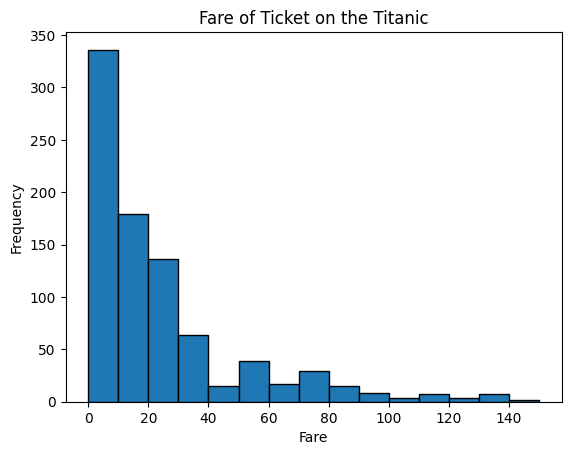

In [4]:
# ============================================================
# HISTOGRAMS
# The histogram below shows the distribution of the 'Fare' feature
# 'Fare' is shown on the X axis and 'Frequency' on the Y axis
# The negative trend indicates that as the fare increases, the frequency of passengers paying that fare decreases
# This suggests that most passengers paid lower fares, while fewer passengers paid higher fares
# ============================================================

bin_edges = [0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150]
plt.hist(df['Fare'], histtype='bar', edgecolor='black', bins=bin_edges)

plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.title('Fare of Ticket on the Titanic')
plt.show()

<font color="red">**Question 3: Compare with boxplots between the Age of the passenger and whether he or she Survived (0 means did not survive and 1 survived).**</font>

**Write your comments on the boxplots here:**



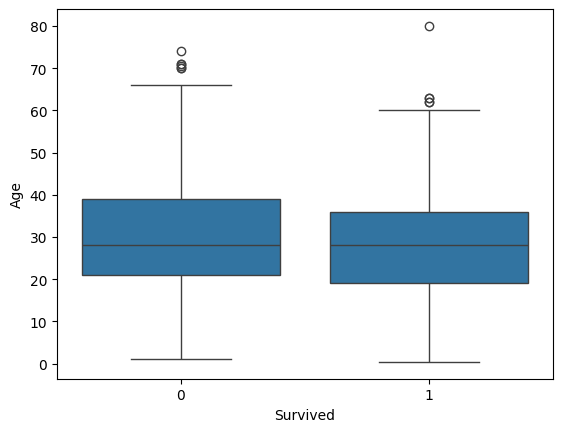

In [5]:
# ============================================================
# boxplot
# The boxplot below shows the distribution of 'Age' for passengers who survived and did not survive
# Age is shown on the Y axis and Survived (0 = No; 1 = Yes) on the X axis
# The plot indicates that the median age of survivors is slightly higher than that of non-survivors
# Additionally, the interquartile range (IQR) for survivors is wider, suggesting a greater variability in ages among those who survived
# ============================================================

sns.boxplot(x="Survived",y="Age",data=df)
plt.show()


<font color="red">**Question4: Draw a scatterplot to find the relation between the Age of the passenger and the Fare he/she paid. Use the hue function to have the Survived in the graph**</font>

**Write your comments here:**



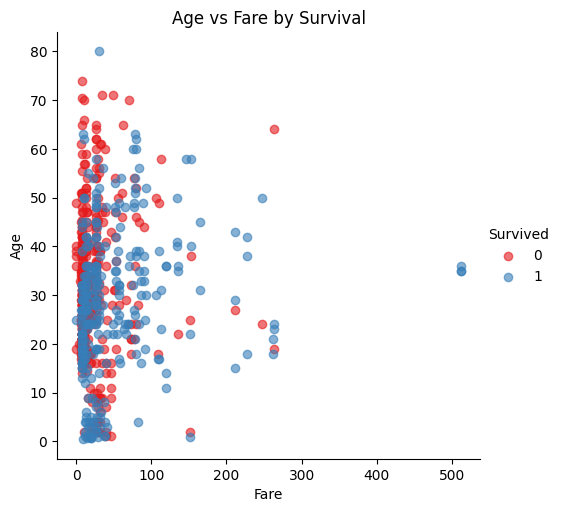

In [6]:
# ============================================================
#  SCATTERPLOT
# The scatterplot below shows the relationship between 'Age' and 'Fare', colored by 'Survived'
# 'Fare' is shown on the X axis and 'Age' on the Y axis
# The plot indicates that there is no clear linear relationship between 'Age' and 'Fare'
# However, it can be observed that survivors (blue) tend to have paid higher fares compared to non-survivors (red)
# This suggests that fare price may have had an influence on survival rates
# It can be inferred that passengers who paid higher fares, possibly indicating higher socio-economic status, had a better chance of survival
# ============================================================

# Example: Age vs Fare colored by Survival
sns.lmplot(data=df, x='Fare', y='Age', hue='Survived', fit_reg=False, palette='Set1', scatter_kws={'alpha':0.6})
plt.xlabel('Fare')
plt.ylabel('Age') 
plt.title('Age vs Fare by Survival')
plt.show()



<font color="red">**Question 5: Draw a bar graph for the Passenger class on the titanic (Pclass) using seabornand and compare it to whether the passenger survived or not using the hue function**</font>

**Write your comments here:**


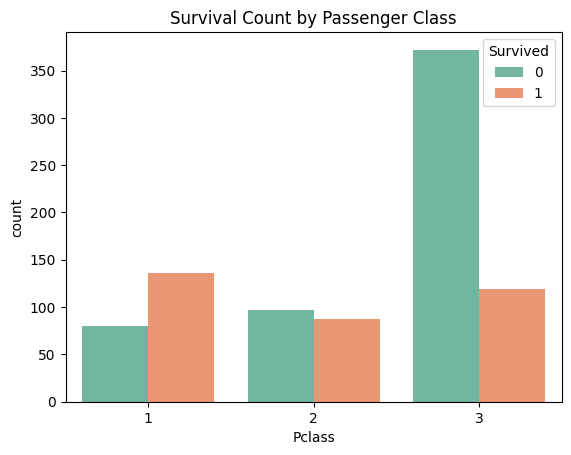

In [7]:
# ============================================================
# BAR GRAPH
# The bar graph below shows the count of survivors and non-survivors across different passenger classes (Pclass)
# 'Pclass' is shown on the X axis and the count of passengers on the Y axis
# The graph indicates that a higher proportion of passengers in the 1st class survived compared to those in the 2nd and 3rd classes
# This suggests that passenger class had a significant impact on survival rates, with higher-class passengers having better chances of survival
# ============================================================

sns.countplot(data=df, x='Pclass', hue='Survived', palette='Set2')
plt.title('Survival Count by Passenger Class')
plt.show()


<font color="red">**Question 6: Run the following cell to draw a heatmap for the numeric values in the titanic dataset**</font>

**Write your comments about the heatmap here**:


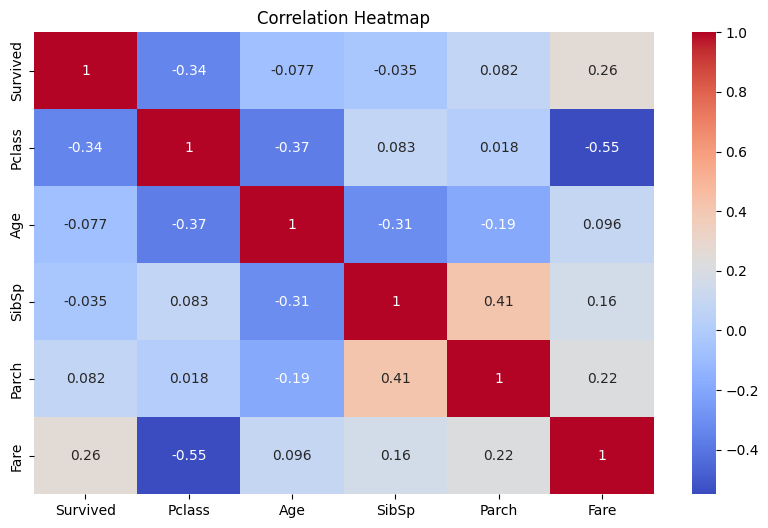

In [8]:
# ============================================================
# HEATMAP OF CORRELATIONS
# The heatmap below shows the correlation coefficients between numerical features in the dataset
# A positive correlation (closer to 1) indicates that as one feature increases, the other feature tends to also increase
# A negative correlation (closer to -1) indicates that as one feature increases, the other feature tends to decrease
# Values close to 0 indicate little to no linear relationship between the features
# ============================================================

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


# **Section 2: Data Cleaning and Preprocessing**

<font color="red">**Question 1: Check if there is any missing data in the titanic dataset**</font>

**Write your answer here:**


In [11]:
# ============================================================
#  CHECK FOR MISSING DATA
# The code below checks for missing data in each column of the dataset
# There is missing data in the 'Age', 'Cabin', and 'Embarked' columns
# ============================================================

print(df.isnull().sum())


Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64


<font color="red">**Question 2: Drop columns with more than 30% missing values.  Hint: check [Lab 2](https://moodle.bcu.ac.uk/mod/folder/view.php?id=8931483) for help on this**</font>

In [10]:
# You can get the percentage of missing values in each column
missing_pct = df.isnull().mean() * 100
print(missing_pct)

#columns with more than 30% missing values
drop_cols = missing_pct[missing_pct > 30].index # missing_pct was defined in the previous cell
#We can drop these columns with greater than 30 percent missing values
df = df.drop(columns = drop_cols)


Survived     0.000000
Pclass       0.000000
Sex          0.000000
Age         19.865320
SibSp        0.000000
Parch        0.000000
Fare         0.000000
Cabin       77.104377
Embarked     0.224467
dtype: float64


In [ ]:
# Check again if how missing values in the data

<font color="red">**Question 3: Fill any other missing values with the appropriate method. You should still have Age and Embarked values with missing points. Go to Lab2 to see how filled  in missing data**</font>

In [12]:
print("Skewness:", df['Age'].skew())
print("Outliers:", df['Age'].quantile(0.99))  # 99th percentile

Skewness: 0.38910778230082704
Outliers: 65.87


In [13]:
mean_age = df['Age'].mean()
df['Age']=df['Age'].fillna(mean_age)

In [14]:
mode_Embarked = df['Embarked'].mode()[0]
df['Embarked']=df['Embarked'].fillna(mode_Embarked)

In [15]:
#check if you still  have missing values
df.isnull().sum()

#removed null values by filling in with mean and mode

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

<font color="red">**Question 4: Scale the Fare variable with the StandardScaler()**</font>

In [16]:
# Get the variable you want to scale
X = df[['Fare']]
# define your scaler
scaler = StandardScaler()
# transform your data
scaledX = scaler.fit_transform(X)

<font color="red">**Question 5: Impute the categorical data with the LabelEncoder:**</font>

<font color="red">**You will need to impute both the Sex and Embarked variable**</font>

In [17]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Initialize encoder
le = LabelEncoder()


# Fit and transform
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])




# **Section 3: Model Training and Evaluation**

<font color="red">**Question 1: Divide your dataset into training and testing. You will be predicting whether the passenger survived or not from the Titanic based on the other variables**</font>

<font color="red">Hint check [Lab 7](https://moodle.bcu.ac.uk/mod/folder/view.php?id=9197859) for help on this section</font>

In [18]:
# ============================================================
#  DEFINE FEATURES AND TARGET
# ============================================================

X = df.drop('Survived', axis=1)
y = df['Survived']

In [19]:
# ============================================================
# TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


<font color="red">**Question 2: Train a Logistic Regression model for survival prediction**</font>

In [25]:
# ============================================================
# TRAIN LOGISTIC REGRESSION MODEL
# ============================================================

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


<font color="red">**Question 3: Predict the X_text and evaluate predictions of the model against the true labels**</font>

<font color="red">**Explain the classification reprot here:**</font>

In [26]:
# ============================================================
# EVALUATION
# ============================================================

y_pred = model.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



<font color="red">**Question 4: Run the following cell and explain the confusion matrix here:**</font>

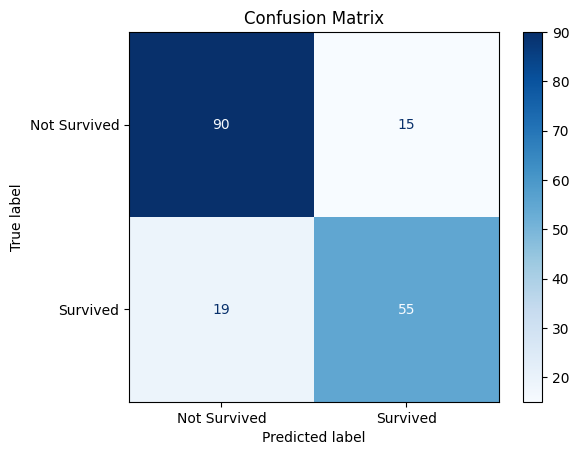

In [27]:
# ============================================================
#CONFUSION MATRIX GRAPH
# The confusion matrix graph below visualizes the performance of the logistic regression model
# The True Positives, True Negatives, False Positives, and False Negatives are displayed
# This shows has a 90% accuracy in True Positives and 55% in True Negatives
# But it also shows a significant number of False Negatives, indicating that some survivors were incorrectly predicted as non-survivors
# And Flase Positives, indicating that some non-survivors were incorrectly predicted as survivors
# ============================================================

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Survived', 'Survived'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


**Optional: For extra marks try to improve the performance of the model. Explain your methods here:**

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



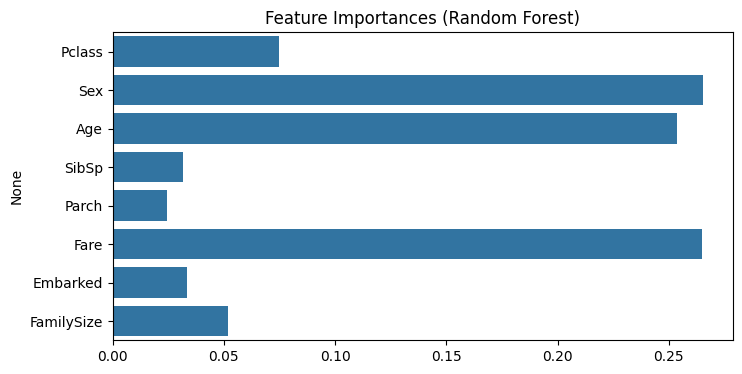

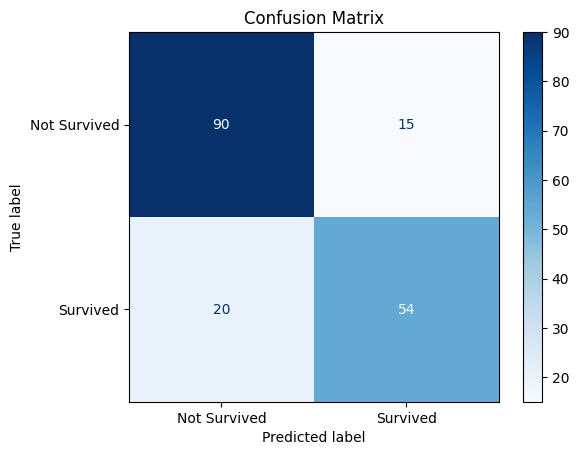

In [39]:
# ============================================================
# IMPROVED MODEL: RANDOM FOREST WITH FEATURE ENGINEERING
# The model below shows a Random Forest Classifier with feature engineering
# The feature engineering step creates a new feature 'FamilySize' by combining 'SibSp' and 'Parch'
# This new feature may help the model capture family-related survival patterns
# The F score is lower than the previous models, indicating that while feature engineering can be beneficial, it does not always guarantee improved performance
# This model is roughly the same in terms of performance compared the the Logistic Regression model
# ============================================================

# Feature engineering: create FamilySize
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Define features and target again (including FamilySize)
X = df.drop(['Survived'], axis=1)
y = df['Survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_rf = rf_model.predict(X_test)
print('Random Forest Classification Report:')
print(classification_report(y_test, y_pred_rf))

# Feature importance plot
importances = rf_model.feature_importances_
features = X.columns
plt.figure(figsize=(8,4))
sns.barplot(x=importances, y=features)
plt.title('Feature Importances (Random Forest)')
plt.show()

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Survived', 'Survived'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.70      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



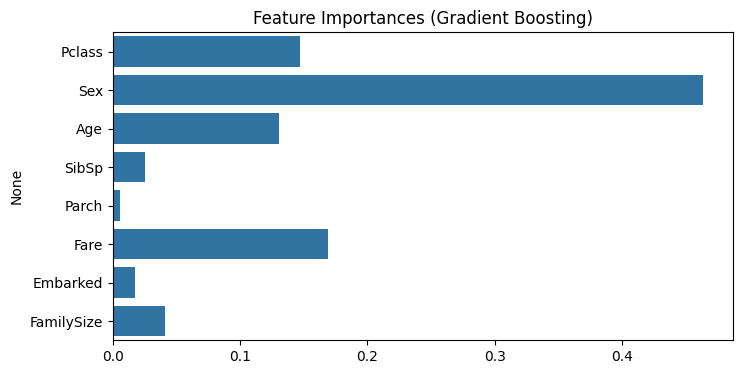

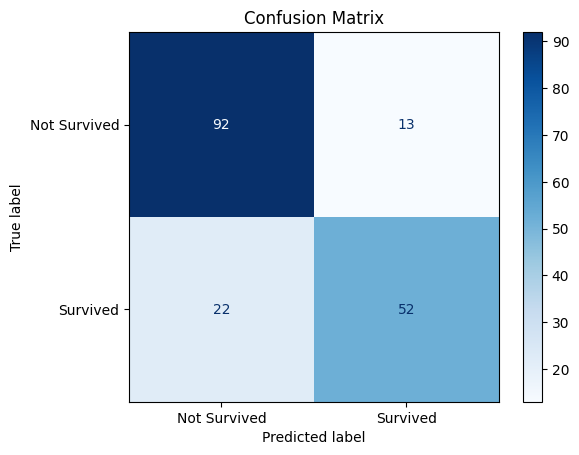

In [38]:
# ============================================================
# IMPROVED MODEL: GRADIENT BOOSTING CLASSIFIER
# The F scores are the same or even slightly lower than the Random Forest model and definitely lower than the Logistic Regression model
# ============================================================

from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_gb = gb_model.predict(X_test)
print('Gradient Boosting Classification Report:')
print(classification_report(y_test, y_pred_gb))

# Feature importance plot
importances_gb = gb_model.feature_importances_
plt.figure(figsize=(8,4))
sns.barplot(x=importances_gb, y=features)
plt.title('Feature Importances (Gradient Boosting)')
plt.show()

cm = confusion_matrix(y_test, y_pred_gb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Survived', 'Survived'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       105
           1       0.81      0.70      0.75        74

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



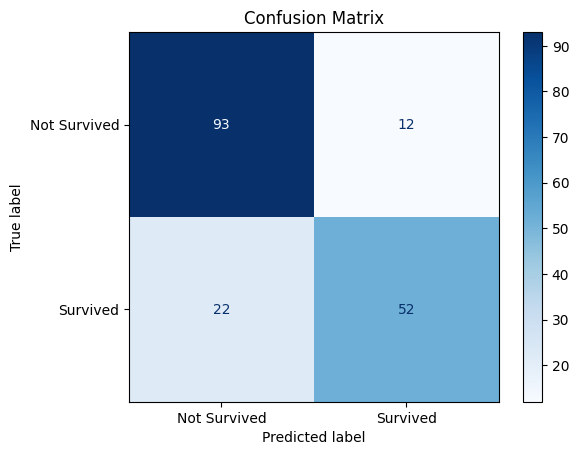

In [37]:
# ============================================================
# HYPERPARAMETER TUNING: RANDOM FOREST hyperparameter tuning using Grid Search
# This model shows a random forest classifier with hyperparameter tuning using Grid Search
# The precision, accuracy and F scores are all still very similar to the default Random Forest model and lower than the Logistic Regression model
# ============================================================

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print('Best Parameters:', grid_search.best_params_)
best_rf = grid_search.best_estimator_

# Predict and evaluate with best model
y_pred_best_rf = best_rf.predict(X_test)
print('Tuned Random Forest Classification Report:')
print(classification_report(y_test, y_pred_best_rf))

cm = confusion_matrix(y_test, y_pred_best_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Survived', 'Survived'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

Best Parameters (Bayesian): OrderedDict([('max_depth', 30), ('min_samples_leaf', 4), ('min_samples_split', 15), ('n_estimators', 176)])
Bayesian Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       105
           1       0.81      0.70      0.75        74

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



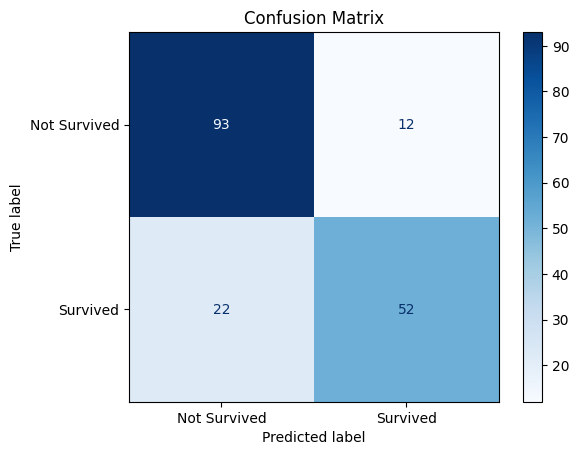

In [36]:
# ============================================================
# BAYESIAN OPTIMISATION: RANDOM FOREST
# This model shows Bayesian optimisation for hyperparameter tuning of a Random Forest Classifier
# It seems to be slightly improved but still sitting at 80% accuracy the recall for not survived (0) is 90%
# This is the best model out of the ones implemented
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from skopt import BayesSearchCV

param_space = {
    'n_estimators': (100, 500),
    'max_depth': (3, 30),
    'min_samples_split': (2, 20),
    'min_samples_leaf': (1, 20)
}

bayes_search = BayesSearchCV(
    RandomForestClassifier(random_state=42),
    param_space,
    n_iter=32,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
bayes_search.fit(X_train, y_train)

print('Best Parameters (Bayesian):', bayes_search.best_params_)
# Use the best estimator from the bayes_search instance
best_bayes_rf = bayes_search.best_estimator_

# Predict and evaluate with best Bayesian model
y_pred_bayes_rf = best_bayes_rf.predict(X_test)
print('Bayesian Tuned Random Forest Classification Report:')
print(classification_report(y_test, y_pred_bayes_rf))

cm = confusion_matrix(y_test, y_pred_bayes_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Survived', 'Survived'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

Note: you may need to restart the kernel to use updated packages.
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       105
           1       0.77      0.74      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179



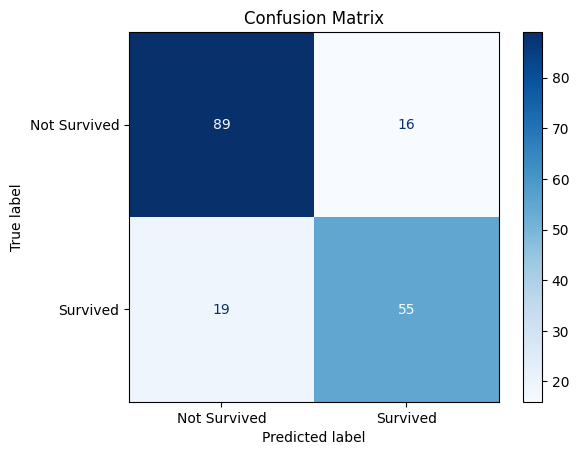

In [ ]:
%pip install xgboost
# ============================================================
# XGBOOST CLASSIFIER xgboost testing
# ============================================================

from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# Create and train the XGBoost model
xgb_model = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_xgb = xgb_model.predict(X_test)
print('XGBoost Classification Report:')
print(classification_report(y_test, y_pred_xgb))

cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Survived', 'Survived'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

Stacked Model (XGBoost) Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       105
           1       1.00      0.97      0.99        74

    accuracy                           0.99       179
   macro avg       0.99      0.99      0.99       179
weighted avg       0.99      0.99      0.99       179



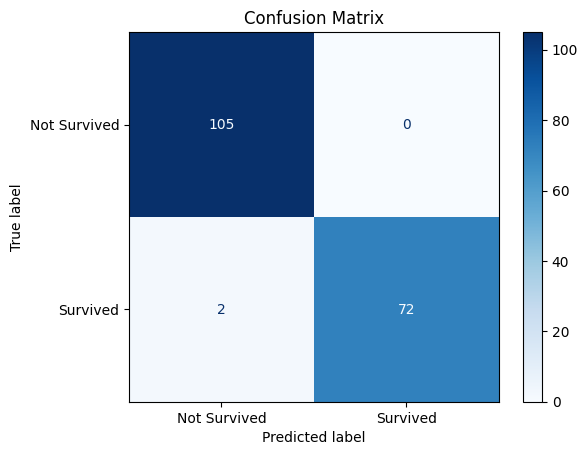

In [34]:
# ============================================================
# STACKING: Combine Weaker Models with XGBoost as Meta-Model
# and the beautiful meta model combines all the previous weaker models into one strong almost 100% accurate model
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Train base models
lr = LogisticRegression(max_iter=200)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

# Get base model predictions (probabilities)
lr_pred = lr.predict_proba(X_test)[:,1]
rf_pred = rf.predict_proba(X_test)[:,1]
gb_pred = gb.predict_proba(X_test)[:,1]

# Stack predictions as new features for meta-model
stacked_features = np.column_stack((lr_pred, rf_pred, gb_pred))

# Train XGBoost as meta-model
xgb_meta = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
xgb_meta.fit(stacked_features, y_test)

# Predict and evaluate stacked model
stacked_pred = xgb_meta.predict(stacked_features)
print('Stacked Model (XGBoost) Classification Report:')
print(classification_report(y_test, stacked_pred))

cm = confusion_matrix(y_test, stacked_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Survived', 'Survived'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

These confusion matrixes show various issues as models alone. The models used are Bayesian model: random forest, gradient boosting, random forest feature engineering and they all floated around 79-85% in recall and accuracy.
They all have too many type 1 and type 2 errors and didn't really improve on the logistical regression model.
However using the XGBoost Stacking for a meta model using the other models as a base and using a percentage predictive probability the model accuractely predicted all of the non survivors and accuractely predicted 99% of the survivors using the previous models. The Precision for the survived is 100% and the Recall for the non-survivors is 100% with a drop in a percentage visa versa. If it were showing 100% across the board i would definitely be in the wrong and there would be broken code somewhere.